### Load libraries

##### The next code block is necessary to get the data. To set it up follow these steps:
1. Sign up to [Roboflow](https://www.roboflow.com)
2. Get an api key from [Roboflow api page](https://app.roboflow.com/settings/api)
3. Go to Kaggle secret and add the key as **roboflow_key**

In [1]:
from kaggle_secrets import UserSecretsClient

# get the roboflow api key from kaggle secret
roboflow_key = UserSecretsClient().get_secret("roboflow_key")
epochs = 15

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=roboflow_key)
project = rf.workspace("bike-helmets").project("bike-helmet-detection-2vdjo")
version = project.version(2)
dataset = version.download("yolo26")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, w


Extracting Dataset Version Zip to Bike-Helmet-Detection-2 in yolo26:: 100%|██████████| 7482/7482 [00:00<00:00, 9472.24it/s] 


In [3]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from glob import glob
import cv2
import math
import matplotlib.pyplot as plt
import os
import gdown

In [5]:
model = YOLO("yolo26s.pt")

### Test without training


0: 640x640 11 persons, 2 motorcycles, 17.2ms
1: 640x640 3 persons, 2 bicycles, 17.2ms
2: 640x640 3 persons, 17.2ms
3: 640x640 1 person, 2 motorcycles, 17.2ms
Speed: 3.5ms preprocess, 17.2ms inference, 7.9ms postprocess per image at shape (1, 3, 640, 640)


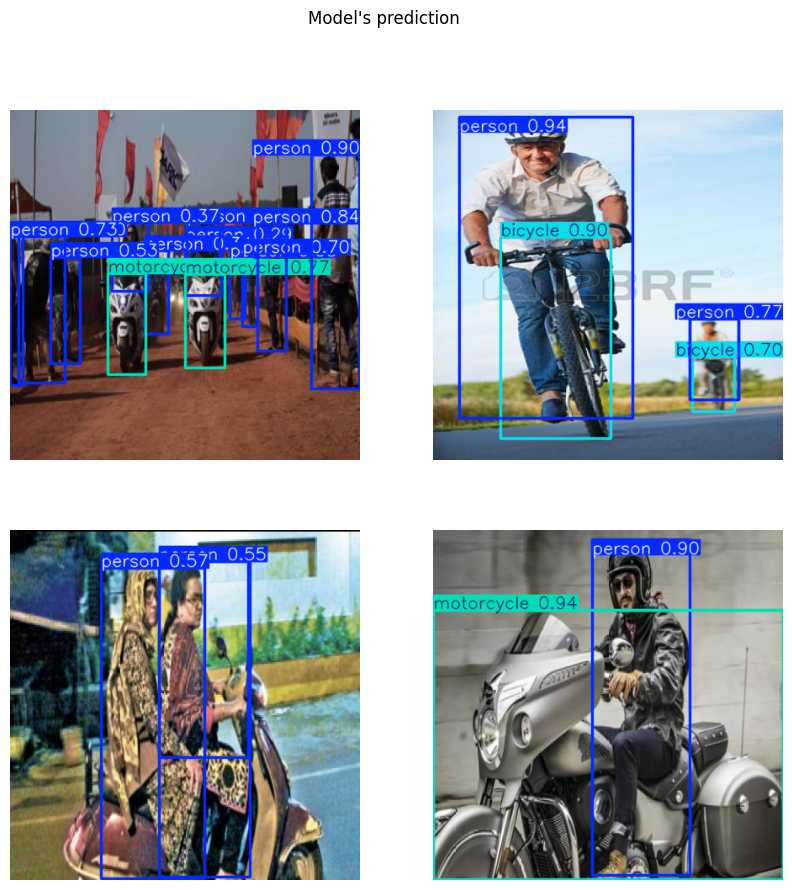

In [6]:
imgs = glob("Bike-Helmet-Detection-2/test/images/*.jpg")

results = model.predict(imgs[:4])

plt.figure(figsize=(10, 10))
for i, result in enumerate(results):
    ax = plt.subplot(2, 2, i+1)
    img = result.plot()      # returns numpy BGR image
    img = img[:, :, ::-1] # Convert BGR to RGB
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Model's prediction")
plt.show()

### Train the model

In [7]:
model.train(data="Bike-Helmet-Detection-2/data.yaml", epochs=epochs, batch=8, imgsz=320, device=[-1, -1])

Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [1, 0]
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:1 (Tesla T4, 14913MiB)
                                                      CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Bike-Helmet-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=1,0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixu

### Test after training

In [8]:
best_model = YOLO("runs/detect/train/weights/best.pt")


0: 320x320 1 With Helmet, 2 Without Helmets, 14.1ms
1: 320x320 2 With Helmets, 14.1ms
2: 320x320 3 Without Helmets, 14.1ms
3: 320x320 1 With Helmet, 14.1ms
Speed: 0.9ms preprocess, 14.1ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)


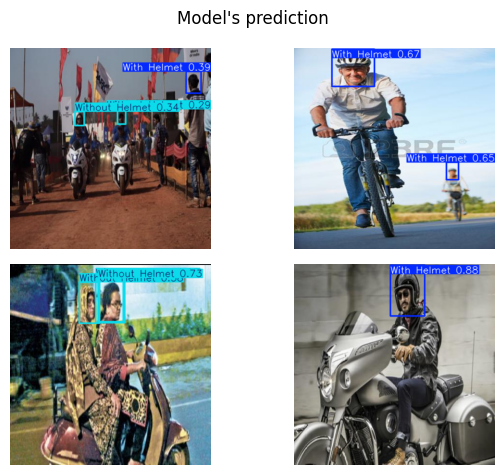

In [9]:
imgs = glob("Bike-Helmet-Detection-2/test/images/*.jpg")
results = best_model.predict(imgs[:4], imgsz=320)

for i, result in enumerate(results):
    ax = plt.subplot(2,2,i+1)
    img = result.plot()      # returns numpy BGR image
    img = img[:, :, ::-1] # Convert BGR to RGB
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Model's prediction")
plt.tight_layout()
plt.show()

In [10]:
drive_url = "https://drive.google.com/uc?id=1KhJiMFK9uV-M4XU-jH6MsI0Mv8mF66Qn"
vid_path = "helmet_detection_test.mp4"

# download video from google drive to test
gdown.download(drive_url, output=vid_path)

Downloading...
From: https://drive.google.com/uc?id=1KhJiMFK9uV-M4XU-jH6MsI0Mv8mF66Qn
To: /kaggle/working/helmet_detection_test.mp4
100%|██████████| 5.85M/5.85M [00:00<00:00, 107MB/s]


'helmet_detection_test.mp4'

In [11]:
cap = cv2.VideoCapture(vid_path)

outputs = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % 15 == 0:
        result = best_model.predict(frame, imgsz=320, verbose=False)
        outputs.append(result[0])  # first result object

    frame_idx += 1

cap.release()

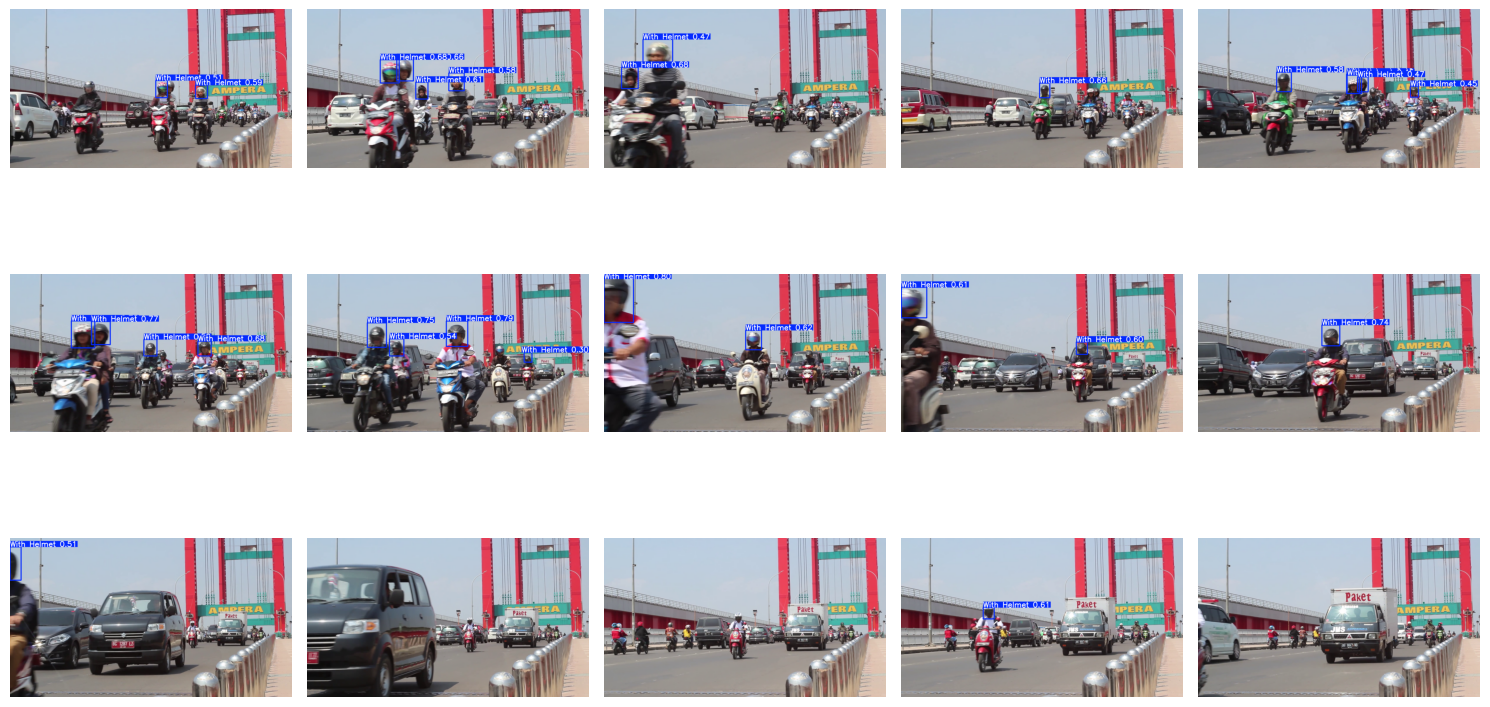

In [12]:
# ----- Plotting -----
num_frames = len(outputs)

cols = 5
rows = math.ceil(num_frames / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten()

for i, out in enumerate(outputs):
    img = out.plot()
    img = img[:, :, ::-1]
    axes[i].imshow(img)
    axes[i].axis("off")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()